In [2]:
#the below is a test, using the first line from the dataset
lines = open("../data/2I_Borisov_obs.txt").read().splitlines()
print(len(lines)) #prints the number of lines (starting at 0)

4023


In [3]:
line0 = lines[0]
print(repr(line0)) #The raw line
print("line0 date: ", line0[15:32]) #the date for this line, with the lower number essentially shifted, as python reads differently than humans
print("line0 ra: ", line0[32:44]) #the right ascencion for this line
print("line0 dec: ", line0[44:56]) #the declination for this line
print("line0 obs: ", line0[77:80]) #info abt the observer for this line

'0002I        KC2018 12 13.47655 04 33 44.86 +63 48 17.6          21.2 RVEV034I41'
line0 date:  2018 12 13.47655 
line0 ra:  04 33 44.86 
line0 dec:  +63 48 17.6 
line0 obs:  I41


In [4]:
import pandas as pd

rows = []
skipped = 0 #this creates a counter for lines we couldn't parse
skipped_pair = 0
for line0 in lines:
    if line0[14].islower(): #any lowercase letter
        skipped_pair += 1
        continue

    #the below is a fix to make the parser detect if there is a shift from an S at the start of the date, from if the observer was a space telescope. This should fix that error.
    off = 0 if line0[15].isdigit() else 1
    rows.append({ #builds a list for the current line of all of its important info (normalizes data)
        "date_str": line0[15+off:32+off].strip(),
        "ra_str":   line0[32+off:44+off].strip(),
        "dec_str":  line0[44+off:56+off].strip(),
        "obscode":  line0[77+off:80+off],
    })

df = pd.DataFrame(rows) #turns the list into a table
print(len(df), "parsed,", skipped, "skipped") #prints how many rows were skipped, and how many made it to the table
df.head() #shows the first five rows of the table

3360 parsed, 0 skipped


,date_str,ra_str,dec_str,obscode
0,2018 12 13.47655,04 33 44.86,+63 48 17.6,I41
1,2019 02 24.18160,04 08 42.59,+57 25 03.7,I41
2,2019 03 17.13972,04 19 26.48,+55 09 07.1,I41
3,2019 03 17.18226,04 19 28.37,+55 08 54.1,I41
4,2019 04 09.15582,04 39 12.31,+52 52 01.6,I41


In [5]:
#This is a validator cell, to ensure that every weird line gets caught before going to the next few cells
looks_ok = df["ra_str"].str.match(r"^\d{2} \d{2} \d{2}") #this line tests every entry in the ra_str column against a pattern, only passing lines that pass the pattern, testing each invididual row. The pattern itself checks to ensure that starting at the very beginning of the string, there are exactly 3 pairs of two digits seperated by spaces.
print((~looks_ok).sum(), "suspicious rows") #the ~ means not, and flips every true to false and visa versa, so looks ok then marks the rows that failed the test, so we know how many failed without creating a new variable. .sum simply counts how many of these failures there are, and the print tells me the quantity
df[~looks_ok].head() #This line prints out the first five rows that didn't pass the test.

0 suspicious rows


,date_str,ra_str,dec_str,obscode


In [6]:
#This column will turn the RA and the Dec into degrees, so they're usable for plotting this data
from astropy.coordinates import SkyCoord #pulls in skyCoord, which is a tool astropy has for representing sky positions
import astropy.units as u #pulling in astropy's system for units (degrees, hours, etc.)

coords = SkyCoord(df["ra_str"], df["dec_str"], unit=(u.hourangle, u.deg)) #feeds the entire RA and Dec columns to SkyCoord at once, and the unit tells it that RA text is in the format of hours-minutes-seconds, while Dec text is in the format of degrees-minutes-seconds
df["ra_deg"] = coords.ra.deg #Creates a new column labeled ra_deg in my table, that contains each RA value now as degrees
df["dec_deg"] = coords.dec.deg #Creates a new column labeled dec_deg in my table, that contains each Dec value now as degrees
df.head() #prints the first five rows, to view the new columns 

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg
0,2018 12 13.47655,04 33 44.86,+63 48 17.6,I41,68.436917,63.804889
1,2019 02 24.18160,04 08 42.59,+57 25 03.7,I41,62.177458,57.417694
2,2019 03 17.13972,04 19 26.48,+55 09 07.1,I41,64.860333,55.151972
3,2019 03 17.18226,04 19 28.37,+55 08 54.1,I41,64.868208,55.148361
4,2019 04 09.15582,04 39 12.31,+52 52 01.6,I41,69.801292,52.867111


In [7]:
#this cell should convert the date text into readible simestamps
from datetime import datetime, timedelta #uses python's built in date tools. datetime is for a moment in time, and time delta is for an amount of time

def parse_date(s): #creates a program called parse_date that takes a text date and returns a timestamp
    y, m, d = s.split() #splits our text into three peices, year, m onth, and day (fraction of a day)
    day_frac = float(d) #converts the text for the day (ex. 08.51765) into a number
    day = int(day_frac) #keeps the whole number part, and seperates the fraction
    frac = day_frac - day #converts the leftover decimal into the fraction of the day that had passed (ex. 0.41196 to abt 9.9 hrs)
    return datetime(int(y), int(m), day) + timedelta(days=frac) #adds the fraction as actual hours.minutes, returns the completed timestamp

df["time"] = df["date_str"].apply(parse_date) # runs the program on every entry within the date_str column in the dataset, and stores the results in a new column it created, time.
df.head() #prints the timestamps for the first 5 rows of the dataset

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
0,2018 12 13.47655,04 33 44.86,+63 48 17.6,I41,68.436917,63.804889,2018-12-13 11:26:13.920
1,2019 02 24.18160,04 08 42.59,+57 25 03.7,I41,62.177458,57.417694,2019-02-24 04:21:30.240
2,2019 03 17.13972,04 19 26.48,+55 09 07.1,I41,64.860333,55.151972,2019-03-17 03:21:11.808
3,2019 03 17.18226,04 19 28.37,+55 08 54.1,I41,64.868208,55.148361,2019-03-17 04:22:27.264
4,2019 04 09.15582,04 39 12.31,+52 52 01.6,I41,69.801292,52.867111,2019-04-09 03:44:22.848


In [8]:
#This cell should administer sanity checks
print("total observations:", len(df)) #len(df) is the number of rows on our table, equilivent to the observations parsed
print("first:", df["time"].min()) #prints out the earliest timesteamp in the time column
print("last: ", df["time"].max()) #prints out the latest timestamp in the time column
print(df["obscode"].value_counts().head(10)) #counts how many times each different observatory code appears, sorted from largest to smallest, and shows the top 10

total observations: 3360
first: 2018-12-13 11:26:13.920000
last:  2020-09-30 06:28:26.140800
obscode
C53    633
954    243
134    169
A84    114
585    105
A77    105
850    100
A71     77
T08     76
G40     51
Name: count, dtype: int64


In [10]:
#quantifies the entries from TESS
sat = df[df["obscode"] == "C57"]
print(len(sat), sat["time"].min())

0 NaT


In [11]:
#This cell sorts our table by time, preparing it for being graphed.
df = df.sort_values("time")
df.tail(3)

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
3357,2020 09 30.244701,15 01 51.293,-55 44 52.26,250,225.463721,-55.747850,2020-09-30 05:52:22.166400
3358,2020 09 30.257224,15 01 52.094,-55 44 51.83,250,225.467058,-55.747731,2020-09-30 06:10:24.153600
3359,2020 09 30.269747,15 01 52.943,-55 44 50.40,250,225.470596,-55.747333,2020-09-30 06:28:26.140800


In [12]:
#This cell will be a true/False mask, with the same pattern as the validator I built earlier
outliers = (df["dec_deg"] > 25) | (df["ra_deg"] > 320) #This lists two conditions, that either the Dec was above 25, or the RA was above 320, joined by or, thresholds coming from simply eyeballing the graph, as no legitemente data should be in this area at all. Note: outliers is in true/false form per row
print(outliers.sum(), "outliers") #counts the quantity of outliers and prints them
df[outliers][["time", "ra_deg", "dec_deg", "obscode"]] #this line shows the flagged rows, but only the four columns I care about from those rows, so I can see exactly when they happened and who subimmited them. 

777 outliers


,time,ra_deg,dec_deg,obscode
0,2018-12-13 11:26:13.920000,68.436917,63.804889,I41
1,2019-02-24 04:21:30.240000,62.177458,57.417694,I41
2,2019-03-17 03:21:11.808000,64.860333,55.151972,I41
3,2019-03-17 04:22:27.264000,64.868208,55.148361,I41
4,2019-04-09 03:44:22.848000,69.801292,52.867111,I41
...,...,...,...,...
772,2019-09-26 05:39:15.494400,139.385158,25.018733,J04
773,2019-09-26 05:41:17.664000,139.385792,25.018222,Z25
774,2019-09-26 05:42:57.024000,139.386042,25.017972,G40
775,2019-09-26 05:52:41.088000,139.389167,25.015389,G40


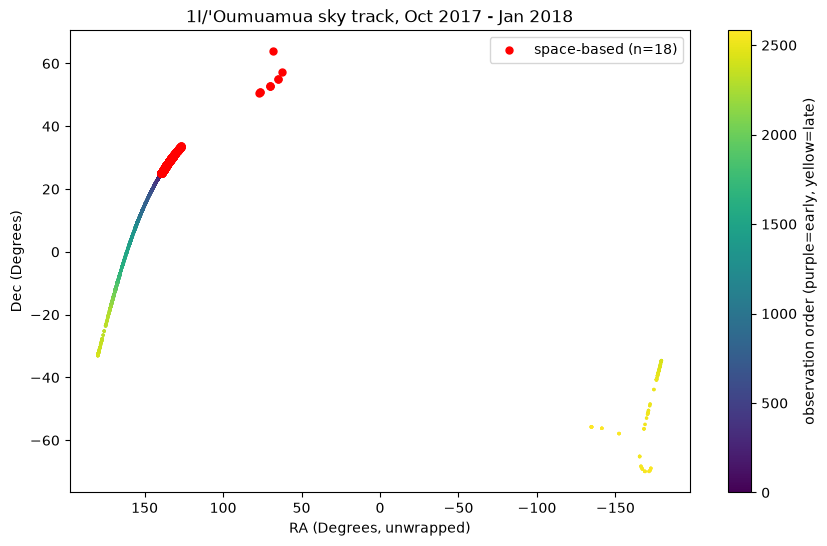

In [ ]:
#This will create a plot of the skytrack of 1I/'Oumuamua throughout all of its available observations
#Comments may be outdated

import matplotlib.pyplot as plt

space_codes = ("250",) #what the census actually found
bad = df["obscode"].isin(space_codes) #if it's a spacecraft, it says that in the records
clean = df[~outliers]
sp = df[outliers]

ra_c = clean["ra_deg"].where(clean["ra_deg"] < 180, clean["ra_deg"] - 360)
ra_s = sp["ra_deg"].where(sp["ra_deg"] < 180, sp["ra_deg"] - 360)

plt.figure(figsize=(10, 6)) #Creates a new blank figure/plot, 10x6 inches
plt.scatter(ra_c, clean["dec_deg"], c=range(len(clean)), cmap="viridis", s=2) #plots all of the "clean" datapoints with the normal color scheme
plt.colorbar(label="observation order (purple=early, yellow=late)") #adds the color legend so that you can actually understand how it relates to time
plt.scatter(ra_s, sp["dec_deg"], color="red", s=25, label=f"space-based (n={bad.sum()})") #Colors the outliers red, and gives them a label for the legend
plt.legend() #Creates a legend
plt.xlabel("RA (Degrees, unwrapped)") #Label for the x-axis
plt.ylabel("Dec (Degrees)") #Label for the y-axis
plt.title("2I/Borsiov sky track, Dec 2018 - Oct 2020") #Titel for the plot
plt.gca().invert_xaxis() #inverts the x-axis
#plt.savefig("../figures/1I_'Oumuamua.png", dpi=150) #saves this to the figures folder as a png file
plt.show()